# A SPICE-Validated $g_m/I_D$ Lookup-Table Flow for a Subthreshold Current-Steering VGA in SKY130

```
Submission to the IEEE SSCS Open-Source Ecosystem "Code-a-Chip" Travel Grant Awards at ISSCC'27
```

| Name | Affiliation | IEEE / SSCS member | Email |
|:--|:--|:--:|:--|
| **Ayush Krishna Balabadra** *(travel-grant applicant)* | VIT Vellore, India | No | ayush.krishna2025@vitstudent.ac.in |
| Vrinda Pandey | VIT Vellore, India | No | vrinda.pandey2025@vitstudent.ac.in |
| Dr. Nawaz Shafi *(faculty advisor)* | VIT Vellore, India | No | nawaz.shafi@vitac.in |

**License:** Apache-2.0 (`SPDX-License-Identifier: Apache-2.0`). Full text in `LICENSE`.

**Reuse and attribution.**

| Reused | Source | Use here |
|:--|:--|:--|
| Lookup-table ($g_m/I_D$) design methodology | P. Jespers and B. Murmann, *Systematic Design of Analog CMOS Circuits Using Pre-Computed Lookup Tables*, CUP 2017 | Device characterisation and LUT-based sizing (§5–§7) |
| LUT-driven spec-to-layout flow structure | A. Adair, Code-a-Chip ISSCC'25 | Overall flow structure |
| LUT + optimisation pattern | A. M. Elhelly, Code-a-Chip ISSCC'26 | Design-space exploration structure |
| Open-source toolchain | IIC-OSIC-TOOLS, ngspice, xschem, SkyWater SKY130 | Everything |

In [9]:
#@ FIG
# Results at a glance - rendered from cache/results.json (written only by the analysis cells below).
import json, pathlib
from IPython.display import Markdown, display
_R = pathlib.Path("cache/results.json")
if not _R.exists():
    display(Markdown("> Run the notebook once to generate `cache/results.json`."))
else:
    R = json.loads(_R.read_text())
    display(Markdown(R.get("tldr_md", "> TL;DR not generated yet - run §12.")))

### TL;DR
A **SPICE-validated $g_m/I_D$ lookup-table flow** for a nine-transistor subthreshold current-steering VGA core
in open SKY130. A LUT evaluator — KCL operating-point solve on interpolated device data with body effect,
plus a full small-signal nodal solve, no SPICE in the loop — predicts gain within **0.31 dB**
and output resistance within **1.2 %** at its calibration point, where the textbook estimate
misses by **22.9 dB** and gets the direction of gain control wrong: the output device is a cascode
on a node the gain control itself modulates. Across 15 SPICE-checked designs spanning
2.5–80 µm widths its error grows to 2.7 dB (SKY130 width binning),
so the flow re-verifies every design it keeps in SPICE. It swept **4,320** candidates under headroom,
current and bandwidth constraints and returns a Pareto front plus two SPICE-verified picks; neither pick dominates the hand-sized baseline:

- **Flow-S** (speed and noise): control range 12.5 dB, max-gain bandwidth 8.7 kHz, integrated input noise 14.8 µV, 5.43 µW; better than the hand-sized baseline on 4 compared metrics (bandwidth at min gain, bandwidth at max gain, integrated noise at max gain, NEF at max gain), worse on 4 (control range, monotonic control range, supply power, output swing at max gain).
- **Flow-R** (range): control range 17.3 dB, max-gain bandwidth 1.9 kHz, integrated input noise 21.5 µV, 2.44 µW; better than the hand-sized baseline on 6 compared metrics (control range, monotonic control range, integrated noise at min gain, integrated noise at max gain, NEF at max gain, supply power), worse on 3 (bandwidth at min gain, bandwidth at max gain, output swing at max gain).
- **Hand-sized baseline:** control range 13.9 dB, max-gain bandwidth 4.8 kHz, integrated input noise 29.1 µV, 3.67 µW.

Flow-S meets 3 of 11 graded targets and Flow-R 2. Every miss is traced to a mechanism
in §9: a structural gain floor, $R_{out}$-shared gain–bandwidth, and flicker noise.

| Evaluator accuracy | Value |
|:--|:--|
| Error vs SPICE at the calibration point (gain / $R_{out}$) | 0.31 dB / 1.2 % |
| Error across the SPICE-checked designs (gain / $R_{out}$) | 2.7 dB / 26 % |
| Textbook-estimate error (gain) | 22.9 dB |
| Candidates swept / feasible / Pareto | 4,320 / 344 / 144 |

| Headline | Baseline (hand) | Flow-S | Flow-R |
|:--|:--:|:--:|:--:|
| Control range, 0–0.3 V / monotonic (dB) | 13.9 / 16.8 | 12.5 / 14.2 | 17.3 / 20.2 |
| $f_{-3dB}$ min / max gain, $C_L$ = 1 pF (kHz) | 11.0 / 4.8 | 17.3 / 8.7 | 6.4 / 1.9 |
| Integrated input noise min / max gain (µV$_{rms}$) | 46.9 / 29.1 | 46.4 / 14.8 | 35.9 / 21.5 |
| Supply current (µA) / power (µW) | 2.04 / 3.67 | 3.01 / 5.43 | 1.35 / 2.44 |


> **Scope.** This work delivers the **variable-gain core** of a hearing-aid dynamic-range compressor
> and the design flow that sizes it. The envelope detector and the closed gain-control loop are **not**
> implemented, so no compression ratio, threshold, knee or attack/release behaviour is claimed (§11.2).

---
## 0. How to run this notebook

| Tier | Needs | What it does | Time |
|:--|:--|:--|:--|
| **1 (default)** | Python 3 + numpy, scipy, pandas, matplotlib | Regenerates every table and figure from the cached data in `cache/` | < 1 min |
| **2** | + ngspice and the SKY130 PDK (e.g. the IIC-OSIC-TOOLS container) | Re-runs every SPICE simulation (`RERUN_SPICE = True`) | ~10 min |
| **3** | as Tier 2 | Re-characterises the devices and re-runs the design-space sweep (`REBUILD_LUT`, `RERUN_SWEEP`) | ~5–20 min |

All simulation logic lives in `scripts/` (`vga_flow.py` SPICE harness, `lut.py` characterisation,
`evaluator.py` LUT model and sweep, `nbutil.py` plumbing); the notebook only orchestrates and reports.
**Every number in the text-generated summaries, tables and the README is read from `cache/results.json`**,
which only analysis code writes — no result is typed by hand.

Cell tags: `#@ SETUP` environment, `#@ CHAR` device characterisation, `#@ DESIGN` LUT-only design work,
`#@ VERIFY` SPICE verification, `#@ FIG` figure/table output.

**Notation.** $g_m$ transconductance, $g_{ds}$ output conductance, $g_{mb}$ body transconductance,
$r_o = 1/g_{ds}$, $U_T = kT/q$, $n$ subthreshold slope factor, $\alpha$ steering fraction,
$R_{out}$ small-signal output resistance, $C_L$ load capacitance, $V_{ctrl}$ differential gain-control voltage.
Device names M1–M9 follow Figure 1.

---
## 1. Introduction

### 1.1 Problem
A hearing-aid compressor maps the wide dynamic range of ambient sound onto the narrow residual range of
an impaired ear. Its gain element sits in the signal path, so its noise sets the instrument's noise
floor and its quiescent current dominates the battery budget. Subthreshold operation is the natural
regime: $g_m/I_D$ is maximal in weak inversion, $\approx 1/(nU_T)$.

Analog subthreshold hearing-aid compression is decades-old prior art — complete analog hearing-aid
processors using log-domain/subthreshold AGC [⟦FILL: VERDI / Sarpeshkar-lineage reference⟧], issued patents
on low-voltage programmable compressors [⟦FILL⟧], and recent open-PDK audio front-end work in SKY130
[⟦FILL: LearnAFE, arXiv 2025⟧]. **The circuit function is not new and is not claimed as new.**

### 1.2 What this work contributes
Sizing a subthreshold transconductor is usually an unrecorded guess-simulate-adjust loop. This notebook
replaces that loop with a **reproducible, SPICE-validated lookup-table flow** and uses it to map — and
honestly bound — what this circuit class can achieve on open silicon:

1. **A LUT-driven circuit evaluator** that predicts the core's operating point, gain, output resistance,
   headroom and bandwidth **with no SPICE in the loop**: a KCL operating-point solve on interpolated
   SKY130 device data (including body effect) followed by a full small-signal nodal solve. Its error
   against SPICE is measured, not assumed: a fraction of a dB at the characterisation width, and larger
   across widths where SKY130's width-binned models depart from the reference — which is why the flow
   re-verifies every design it keeps in SPICE (§6, §7.1).
2. **A device-level explanation of the gain-control law.** The textbook estimate (steering fraction ×
   input $g_m$ × output $r_o$) misses that the output device is a *cascode on a node whose impedance the
   gain control itself modulates*; the evaluator captures this, the textbook estimate does not (§6).
3. **A structural limit, found and explained:** the steering fraction and the output resistance cancel
   below mid-scale, creating a gain floor that no sizing removes (§4.2).
4. **A mapped design space** (§7): every candidate in a multi-dimensional sizing/bias grid evaluated
   against headroom, current and bandwidth constraints, a Pareto front, and SPICE confirmation of the
   front.
5. **Verified design picks.** The flow returns the Pareto front and two named picks from it, each verified
   in SPICE for every figure of merit — including the ones it fails — with a diagnosed cause for each miss,
   and compares them with the hand-sized baseline without assuming the flow beats it (§8, §9).

Two defects found during development are recorded rather than hidden, because each became a design
rule enforced by the flow (§4.3).

---
## 2. Environment

In [23]:
#@ SETUP
# ------------------------------------------------------------------ run-mode flags
REBUILD_LUT = False   # Tier 3: re-characterise SKY130 devices into cache/lut_sky130.npz (~3 min)
RERUN_SWEEP = False   # Tier 3: re-run the LUT-only design-space sweep -> cache/sweep.csv
RERUN_SPICE = False   # Tier 2: re-run every SPICE simulation (otherwise read cache/*.json)

import os, sys, json, math, platform, subprocess, shutil
from pathlib import Path
os.environ.setdefault("PDK_ROOT", "/foss/pdks")          # IIC-OSIC-TOOLS default
sys.path.insert(0, str(Path.cwd() / "scripts"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nbutil as nu, vga_flow as vf, lut as lutmod, evaluator as ev
nu.plot_style()

SPICE_OK = nu.spice_available(vf.PDK_LIB)
if (RERUN_SPICE or REBUILD_LUT or RERUN_SWEEP) and not SPICE_OK and (RERUN_SPICE or REBUILD_LUT):
    print("ngspice/SKY130 not found -> falling back to Tier 1 (cached data).")
    RERUN_SPICE = REBUILD_LUT = False
nu.CAN_RUN = SPICE_OK      # missing caches are regenerated automatically when SPICE is present
CL = 1e-12                 # load capacitance used for every bandwidth figure [F]
BAND = (20.0, 20e3)        # audio band for integrated noise [Hz]
N_REF = 1.5973             # n from an independent isolated-device fit (Phase-1 lab notebook)
BASE = dict(vf.BASELINE)   # hand-sized baseline design (see Table 3)
print(f"SPICE available: {SPICE_OK}   PDK: {vf.PDK_LIB}")
print(f"RERUN_SPICE={RERUN_SPICE}  REBUILD_LUT={REBUILD_LUT}  RERUN_SWEEP={RERUN_SWEEP}")

SPICE available: True   PDK: /foss/pdks/sky130A/libs.tech/ngspice/sky130.lib.spice
RERUN_SPICE=False  REBUILD_LUT=False  RERUN_SWEEP=False


In [24]:
#@ SETUP
# Record the toolchain actually used (Table 1). Cached so Tier-1 runs still show it.
def _env():
    import re
    e = {"python": sys.version.split()[0], "platform": platform.platform(),
         "numpy": np.__version__, "pandas": pd.__version__}
    import scipy, matplotlib; e["scipy"] = scipy.__version__; e["matplotlib"] = matplotlib.__version__
    try:
        o = subprocess.run(["ngspice", "-v"], capture_output=True, text=True, timeout=20).stdout
        e["ngspice"] = next((m.group(0) for m in (re.search(r"ngspice-[0-9][0-9.]*", l) for l in o.splitlines()) if m), "?")
    except Exception:
        e["ngspice"] = "not found"
    e["PDK_ROOT"] = os.environ.get("PDK_ROOT")
    src = Path(os.environ.get("PDK_ROOT", "")) / "sky130A" / "SOURCES"
    e["sky130A build"] = " ".join(src.read_text().split()[:3]) if src.exists() else "version file not found"
    return e
ENV = nu.cached("environment", _env, RERUN_SPICE)
nu.show_md("*Table 1. Toolchain used to produce the results in this notebook.* Layout tools "
           "(Magic, Netgen, KLayout) are recorded in §10 if layout is included.\n\n" +
           nu.md_table(["Tool", "Version"], [[k, v] for k, v in ENV.items()]))

*Table 1. Toolchain used to produce the results in this notebook.* Layout tools (Magic, Netgen, KLayout) are recorded in §10 if layout is included.

| Tool | Version |
|:--|:--:|
| python | 3.12.3 |
| platform | Linux-6.12.76-linuxkit-aarch64-with-glibc2.39 |
| numpy | 2.5.2 |
| pandas | 3.0.5 |
| scipy | 1.18.0 |
| matplotlib | 3.11.1 |
| ngspice | ngspice-47 |
| PDK_ROOT | /foss/pdks |
| sky130A build | open_pdks 026824c7969ce6f4fc9678e6ca04b0a06a596c4b |

---
## 3. Circuit and analytical model

### 3.1 Topology
![Figure 1. VGA core topology](images/schematic_vga.png)

*Figure 1. Nine-transistor current-steering VGA core. M1–M5: current-mirror OTA. M6–M9: steering stage.*

| Node | Pins | | Node | Pins |
|:--|:--|:--|:--|:--|
| `vdd` | M1.S, M4.S, M7.D, M8.D, **PMOS wells** | | `net4` (mirror) | M1.D, M1.G, M6.D, M4.G |
| `net5` (tail) | M2.S, M3.S, M5.D | | `v_out` | M4.D, M9.D |
| `net2` (node A) | M2.D, M6.S, M7.S | | `vctrl_p` / `vctrl_n` | M6.G, M9.G / M7.G, M8.G |
| `net3` (node B) | M3.D, M8.S, M9.S | | NMOS bodies | ground |

The input pair converts $v_{id}$ to a differential current. Each branch current is split by a steering
pair into an output path (M6 → mirror, M9 → output) and a dump path to $V_{DD}$ (M7, M8). M1/M4 mirror
the A-side output onto `v_out`, making the stage single-ended and **non-inverting** (both paths drive
`v_out` the same way for positive $v_{id}$). A diode-loaded differential alternative was rejected: in weak
inversion $g_m = I_D/(nU_T)$ is set by current alone, so its gain is capped at $g_{mn}/g_{mp}$ regardless
of sizing (measured 4.5 dB on an early build).

### 3.2 Steering law
M6 and M7 share a source, so in weak inversion

$$
\alpha(V_{ctrl}) = \frac{I_6}{I_6+I_7} = \frac{1}{1+e^{-(V_{ctrl}-V_{off})/(nU_T)}},
$$

and because $g_m \propto I_D$ in weak inversion the small-signal split equals the DC split. $V_{off}$ is a
small systematic offset: M7's drain sits at $V_{DD}$ and M6's at the mirror node, so finite output
resistance gives M7 slightly more current at equal gate drive. For $V_{ctrl} \ge 0$, $\alpha$ can only
rise from ≈0.5 to 1, so **the steering term alone can contribute at most ≈6 dB of gain change**.

### 3.3 Gain model
$$
A_v = \alpha \, g_{m2}\, R_{out}, \qquad
R_{out} = \Big[\, r_{o9} + R_B + g_{m9}\, r_{o9}\, R_B \,\Big] \,\Big\|\, r_{o4}, \qquad
R_B = r_{o3} \,\|\, \frac{1}{g_{m8}} .
$$

M9's source is node B, an active node, so **M9 is a cascode on M3**. As $V_{ctrl}$ rises, the dump device
M8 cuts off, $g_{m8}$ collapses, $R_B$ rises and the cascode boost rises with it. The same control voltage
that steers the current also raises the output resistance — which is why the measured control range
exceeds the 6 dB steering bound. The textbook estimate $\alpha g_{m2}(r_{o4}\|r_{o9})$ omits this term.

### 3.4 Gain floor
For $V_{ctrl} < 0$, M8 is fully on so $R_B \approx 1/g_{m8}$ stays small and $R_{out} \approx r_{o9}\|r_{o4}$.
Both output devices carry $\alpha I_{branch}$, so $r_o \propto 1/\alpha$ while the delivered
transconductance $\propto \alpha$: **the two cancel, and gain flattens to a floor**
$\approx g_{m2}\,(r_{o9}\|r_{o4})\big|_{I_{branch}}$ that sizing cannot remove. §4.2 measures it.

### 3.5 Target specification
*Table 2. Targets, fixed before characterisation unless marked revised.*

| Parameter | Target | Rationale |
|:--|:--:|:--|
| Supply $V_{DD}$ | 1.8 V | SKY130 nominal |
| Total current $I_{tot}$ | ≤ 5 µA | Hearing-aid budget; prior art at 1.8 V ⟦FILL ref⟧ |
| Gain-control range $\Delta A_v$ | ≥ 30 dB | WDRC compression range (single stage) |
| $f_{-3\,dB}$ at **every** gain setting, $C_L = 1$ pF | ≥ 10 kHz | Audio band; $C_L$ = assumed next-stage input |
| Input noise density at 1 kHz | ≤ 50 nV/√Hz | ⟦FILL ref⟧ |
| Integrated input noise, 20 Hz–20 kHz | ≤ 7 µV$_{rms}$ | 50 nV/√Hz × √20 kHz |
| NEF | ≤ 5 | Prior-art comparison |
| Linearity | *revised:* report max output swing at THD ≤ 1 % | The original "THD ≤ 1 % at 10 mV$_{pp}$ input" is unreachable by construction at ≥ 40 dB gain (≥ 1 V$_{pp}$ output) |
| Device headroom $V_{DS}$ (M2, M3, M5, M6, M9) | ≥ 130 mV at both control endpoints | *added* after the defect in §4.3 (≈5 $U_T$, weak-inversion saturation) |

---
## 4. Baseline: the hand-sized core, characterised in SPICE

The baseline is the design as reached by manual iteration (Table 3). It is characterised first because
(i) it validates the analytical model of §3, (ii) it is the reference the flow must beat, and (iii) it
is where both development defects were found.

*Table 3. Baseline geometry and bias.*

| Device | Role | W / L (µm) |
|:--|:--|:--:|
| M2, M3 | input pair | 20 / 1 |
| M6–M9 | steering | 5 / 1 |
| M1, M4 | PMOS mirror | 5 / 1 |
| M5 | tail | 5 / 1 |

Bias: $V_{DD}$ = 1.8 V, $V_{bias}$ = 0.61 V, input common mode 0.9 V, steering common mode
$V_{ctrl,cm}$ = 1.15 V, $v_{ctrl,p/n} = V_{ctrl,cm} \pm V_{ctrl}/2$. Gain is measured by `.ac` at 100 Hz;
$R_{out}$ by injecting a 1 A AC test current at `v_out` with the input silent.

In [25]:
#@ VERIFY
# Baseline characterisation at both control endpoints, for four netlist/bias variants:
#   float_cm120 : as first built  - PMOS wells floating (defect 1), steering CM 1.20 V
#   tied_cm120  : wells tied to vdd, CM 1.20 V
#   tied_cm095  : wells tied, CM 0.95 V (the original bias: defect 2)
#   tied_cm115  : wells tied, CM 1.15 V  <- the baseline used everywhere else
VARIANTS = {"float_cm120": dict(pmos_body="float", vctrl_cm=1.20),
            "tied_cm120":  dict(vctrl_cm=1.20),
            "tied_cm095":  dict(vctrl_cm=0.95),
            "tied_cm115":  dict(vctrl_cm=1.15)}
def _baseline():
    return {k: {f"{v:.1f}": vf.characterise(dict(BASE, **ov), v) for v in (0.0, 0.3)}
            for k, ov in VARIANTS.items()}
B = nu.cached("baseline", _baseline, RERUN_SPICE)
b0, b3 = B["tied_cm115"]["0.0"], B["tied_cm115"]["0.3"]

rows = []
for k in VARIANTS:
    for v in ("0.0", "0.3"):
        r = B[k][v]
        rows.append([k, v, f"{r['av_db']:.2f}", f"{r['rout']/1e6:.2f}", f"{r['alpha']:.4f}",
                     f"{100*r['delivery']:.0f} %", f"{1e3*r['m2_vds']:.0f}", f"{1e3*r['m9_vds']:.0f}",
                     f"{1e3*r['m5_vds']:.0f}", f"{r['v_out']:.4f}"])
nu.show_md("*Table 4. Baseline operating point and gain at both control endpoints (tt, 27 °C).* "
           "Delivery = measured $A_v/R_{out}$ divided by the model's $\\alpha g_{m2}$.\n\n" +
           nu.md_table(["variant", "V_ctrl", "A_v (dB)", "R_out (MΩ)", "α", "delivery",
                        "V_DS M2 (mV)", "V_DS M9 (mV)", "V_DS M5 (mV)", "v_out (V)"], rows))

# Model check: does A_v = alpha * gm2 * R_out hold, term by term?
chk = [[v, f"{r['alpha']:.4f}", f"{1e6*r['m2_gm']:.2f}", f"{r['rout']/1e6:.2f}",
        f"{r['gm_model']*r['rout']:.1f}", f"{r['av']:.1f}", f"{100*(r['gm_model']*r['rout']/r['av']-1):+.2f} %"]
       for v, r in (("0", b0), ("0.3", b3))]
nu.show_md("*Table 5. The gain model with every term measured independently in SPICE (baseline).*\n\n" +
           nu.md_table(["V_ctrl", "α", "g_m2 (µS)", "R_out (MΩ)", "α·g_m2·R_out", "A_v measured", "error"], chk))

R = nu.record(base_av_lo_db=b0["av_db"], base_av_hi_db=b3["av_db"], base_range_db=b3["av_db"]-b0["av_db"],
              base_rout_lo=b0["rout"], base_rout_hi=b3["rout"], base_itot=b0["i_tot"], base_power=b0["power"],
              base_model_err_pct=max(abs(r["gm_model"]*r["rout"]/r["av"]-1) for r in (b0, b3))*100,
              defect_cm095_delivery=B["tied_cm095"]["0.0"]["delivery"],
              defect_cm095_m2vds=B["tied_cm095"]["0.0"]["m2_vds"],
              defect_float_nwell=B["float_cm120"]["0.0"].get("v_nwell"),
              defect_float_m9vds=B["float_cm120"]["0.3"]["m9_vds"], defect_tied_m9vds=B["tied_cm120"]["0.3"]["m9_vds"])

*Table 4. Baseline operating point and gain at both control endpoints (tt, 27 °C).* Delivery = measured $A_v/R_{out}$ divided by the model's $\alpha g_{m2}$.

| variant | V_ctrl | A_v (dB) | R_out (MΩ) | α | delivery | V_DS M2 (mV) | V_DS M9 (mV) | V_DS M5 (mV) | v_out (V) |
|:--|:--:|:--:|:--:|:--:|:--:|:--:|:--:|:--:|:--:|
| float_cm120 | 0.0 | 43.82 | 13.50 | 0.4582 | 100 % | 220 | 279 | 323 | 0.8217 |
| float_cm120 | 0.3 | 57.72 | 30.86 | 0.9996 | 99 % | 316 | 138 | 324 | 0.7776 |
| tied_cm120 | 0.0 | 43.82 | 13.52 | 0.4575 | 100 % | 220 | 268 | 323 | 0.8108 |
| tied_cm120 | 0.3 | 57.60 | 30.44 | 0.9996 | 99 % | 315 | 123 | 324 | 0.7631 |
| tied_cm095 | 0.0 | 37.38 | 12.65 | 0.4607 | 55 % | 28 | 475 | 307 | 0.8106 |
| tied_cm095 | 0.3 | 57.36 | 30.36 | 0.9996 | 97 % | 109 | 332 | 322 | 0.7631 |
| tied_cm115 | 0.0 | 44.34 | 14.37 | 0.4584 | 100 % | 178 | 309 | 323 | 0.8107 |
| tied_cm115 | 0.3 | 58.22 | 32.70 | 0.9996 | 99 % | 274 | 165 | 324 | 0.7631 |

*Table 5. The gain model with every term measured independently in SPICE (baseline).*

| V_ctrl | α | g_m2 (µS) | R_out (MΩ) | α·g_m2·R_out | A_v measured | error |
|:--|:--:|:--:|:--:|:--:|:--:|:--:|
| 0 | 0.4584 | 25.13 | 14.37 | 165.5 | 164.9 | +0.37 % |
| 0.3 | 0.9996 | 25.14 | 32.70 | 821.8 | 814.3 | +0.92 % |

### 4.2 Gain-control characteristic and the gain floor

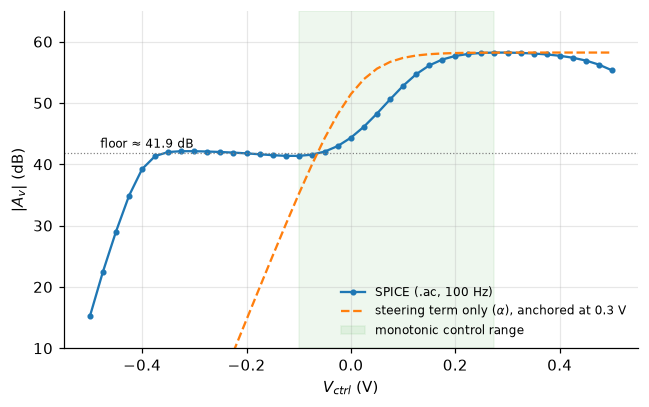

monotonic span -0.100 .. +0.275 V : 41.37 -> 58.22 dB  (16.85 dB)
gain floor (median over -0.35..-0.05 V): 41.90 dB;  steering offset V_off = +6.9 mV


In [13]:
#@ VERIFY #@ FIG
VGRID = np.round(np.arange(-0.5, 0.5001, 0.025), 4)
G = nu.cached("gain_curve_baseline",
              lambda: dict(vctrl=VGRID, av=vf.gain_curve(dict(BASE), VGRID)), RERUN_SPICE)
gv, ga = np.array(G["vctrl"]), 20*np.log10(np.array(G["av"]))

def monotonic_span(v, a_db):
    # largest interval around V_ctrl = 0 on which gain rises monotonically with V_ctrl
    i0 = int(np.argmin(abs(v))); lo = hi = i0
    while lo > 0 and a_db[lo-1] < a_db[lo]: lo -= 1
    while hi < len(v)-1 and a_db[hi+1] > a_db[hi]: hi += 1
    return lo, hi
lo, hi = monotonic_span(gv, ga)
floor_db = float(np.median(ga[(gv >= -0.35) & (gv <= -0.05)]))

# steering-only prediction, anchored at the measured maximum-gain point
UT = vf.K_B*300.15/vf.Q
v_off = -N_REF*UT*math.log(b0["alpha"]/(1-b0["alpha"]))            # offset implied by alpha(0)
alpha = lambda v: 1/(1+np.exp(-(v - v_off)/(N_REF*UT)))
i3 = int(np.argmin(abs(gv-0.3)))
steer_only = ga[i3] + 20*np.log10(alpha(gv)/alpha(gv[i3]))

fig, ax = plt.subplots()
ax.plot(gv, ga, "o-", ms=3, label="SPICE (.ac, 100 Hz)")
ax.plot(gv, steer_only, "--", label=r"steering term only ($\alpha$), anchored at 0.3 V")
ax.axhline(floor_db, color="gray", lw=0.8, ls=":"); ax.text(-0.48, floor_db+0.8, f"floor ≈ {floor_db:.1f} dB", fontsize=8)
ax.axvspan(gv[lo], gv[hi], color="C2", alpha=0.08, label="monotonic control range")
ax.set_ylim(10, 65); ax.set_xlabel(r"$V_{ctrl}$ (V)"); ax.set_ylabel(r"$|A_v|$ (dB)"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(nu.FIGS / "gain_curve_baseline.png")
plt.show()
print(f"monotonic span {gv[lo]:+.3f} .. {gv[hi]:+.3f} V : {ga[lo]:.2f} -> {ga[hi]:.2f} dB  ({ga[hi]-ga[lo]:.2f} dB)")
print(f"gain floor (median over -0.35..-0.05 V): {floor_db:.2f} dB;  steering offset V_off = {1e3*v_off:+.1f} mV")
R = nu.record(base_floor_db=floor_db, base_mono_lo_v=gv[lo], base_mono_hi_v=gv[hi],
              base_mono_range_db=ga[hi]-ga[lo], base_peak_db=float(ga.max()), v_off_mv=1e3*v_off)

*Figure 2. Baseline gain versus control voltage (tt, 27 °C).* Three regions are visible.
**(i)** For $V_{ctrl} \gtrsim 0$ gain rises far faster than the steering term alone predicts — the excess is
the cascode $R_{out}$ term of §3.3. **(ii)** For moderately negative $V_{ctrl}$ gain is **flat**: the floor
predicted in §3.4, where the falling steering fraction is cancelled by the rising output resistance of
devices whose bias current it also sets. **(iii)** Below roughly −0.4 V the steering devices approach cutoff
and gain collapses steeply; this region is not a usable control law (highly nonlinear and, being set by
nA-level currents, strongly PVT-dependent). The usable control range is therefore the shaded monotonic
span, and **a single stage of this topology cannot reach the 30 dB target at any sizing** — §7 confirms
this across the design space rather than asserting it.

### 4.3 Development record: two defects, two design rules
1. **Floating PMOS wells.** In the first schematic the PMOS body pins connected to a net named `VDD`
   while the supply drove a different net, leaving the n-wells floating (they settled ≈40 mV below the
   supply, a slight forward body bias). Gain was nearly unaffected, but `v_out` sat higher and the
   output device M9 appeared to have more headroom than it does (Table 4, `float_cm120` vs `tied_cm120`).
   *Rule:* the harness ties wells explicitly; LVS would also flag this.
2. **Input pair out of saturation.** At the original steering common mode (0.95 V) the input pair's
   drain–source voltage collapsed to a few $U_T$; its output conductance rivalled its $g_m$ and it
   delivered only about half its transconductance at the low-gain end (Table 4, `tied_cm095`: delivery).
   That loss masqueraded as extra control range. Re-centring the steering common mode restored
   ≈100 % delivery. *Rule:* $V_{DS} \ge 130$ mV on M2, M3, M5, M6, M9 at **both** control endpoints is a
   hard constraint in the flow (§7), which adds a 20 mV design margin.

---
## 5. Device characterisation: the lookup table

Both SKY130 devices are swept once and stored per unit width. Body effect matters here: all NMOS
bodies are at ground while six of nine NMOS sources sit 0.3–0.6 V above it, so source–body voltage is a
table axis.

*Table 6. Characterisation grid.* nfet: $L \in \{0.5, 1, 2\}$ µm, $V_{GS}$ 0–1.2 V / 5 mV,
$V_{DS}$ 0–1.8 V / 25 mV, $V_{SB} \in \{0, 0.15, \ldots, 0.75\}$ V. pfet: same $L$ and $V_{DS}$,
$|V_{GS}|$ 0–1.8 V / 5 mV, $V_{SB}=0$ (wells at the source). Reference width 5 µm; stored quantities
$I_D$, $g_m$, $g_{ds}$, $g_{mb}$, $V_{TH}$. Interpolation: $\ln I_D$ and the ratios $g/I_D$, multilinear.

*Table 7. LUT acceptance gates. The last row is reported, not gated: it is the source of the evaluator's tail-voltage error and is absorbed by the headroom margin (§6).*

| Check | Compared | Error | Pass |
|:--|:--:|:--:|:--:|
| n fitted over 0.35–0.60 V (L = 1 µm) vs independent fit | 1.5966 vs 1.5973 | -0.05 % | ✅ |
| M5 drain current at the baseline operating point | LUT vs SPICE | -0.00 % | ✅ |
| M2 g_m/I_D at its SPICE current (W = 20 µm, V_SB = tail) | LUT vs SPICE | -1.99 % | ✅ |
| M1 drain current (pfet) | LUT vs SPICE | -0.00 % | ✅ |
| V_GS offset at equal current, 20 µm vs 5 µm reference (width binning) | LUT vs SPICE | +12.8 mV | info |

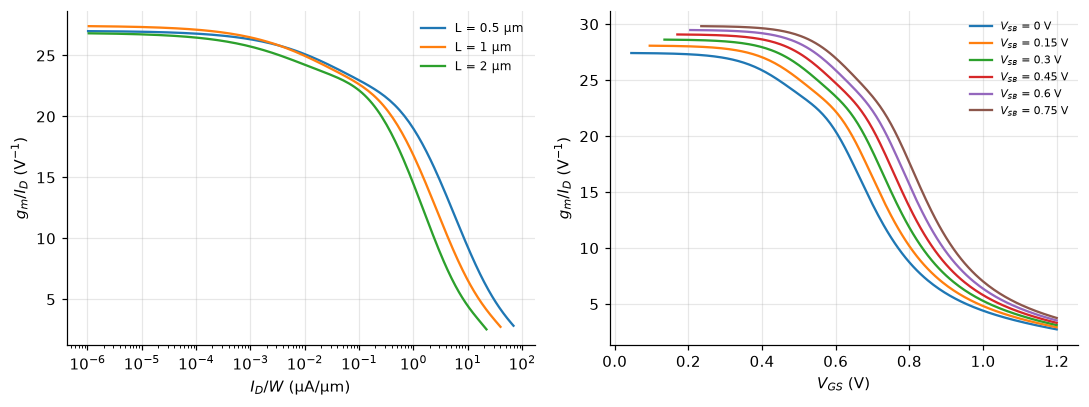

peak g_m/I_D (L=1 µm, V_DS=0.5 V) = 27.43 /V  ->  n_min = 1.409


In [14]:
#@ CHAR
LUT_PATH = nu.CACHE / "lut_sky130.npz"
if REBUILD_LUT:
    LUT = lutmod.build(); lutmod.save(LUT, LUT_PATH)
LUT = lutmod.load(LUT_PATH)

# ---- acceptance gates: the table must reproduce independent measurements before anything uses it
d = LUT["nfet"]; iL = list(d["L"]).index(1.0); k = int(np.argmin(abs(d["vds"] - 0.5)))
vg, idv = d["vgs"], d["id"][iL, 0, k]; m = (vg >= 0.35) & (vg <= 0.60)
n_lut = 1/(np.polyfit(vg[m], np.log(idv[m]), 1)[0]*UT)
gmid = d["gm"][iL, 0, k]/np.maximum(idv, 1e-30)
nin, ntl, pm = lutmod.Device(LUT, "nfet", 1.0), lutmod.Device(LUT, "nfet", 1.0), lutmod.Device(LUT, "pfet", 1.0)
from scipy.optimize import brentq
g_m5 = ntl.id(5, BASE["vbias"], b0["m5_vds"], 0) / b0["m5_id"] - 1
# Input pair (W = 20 um) is interpolated from the 5 um reference. SKY130 models are binned by width, so
# compare at the SPICE drain current (what the evaluator actually uses), and report the V_GS offset.
vg2 = brentq(lambda v: math.log(nin.id(20, v, b0["m2_vds"], b0["v_tail"])) - math.log(b0["m2_id"]), 0.2, 1.0)
o2 = nin.op(20, vg2, b0["m2_vds"], b0["v_tail"])
g_m2 = (o2["gm"]/o2["id"]) / (b0["m2_gm"]/b0["m2_id"]) - 1
dvgs_mv = 1e3*(vg2 - b0["m2_vgs"])
g_m1 = pm.id(5, abs(b0["m1_vgs"]), abs(b0["m1_vds"])) / b0["m1_id"] - 1
gates = [["n fitted over 0.35–0.60 V (L = 1 µm) vs independent fit", f"{n_lut:.4f} vs {N_REF}", f"{100*(n_lut/N_REF-1):+.2f} %", abs(n_lut/N_REF-1) < 0.02],
         ["M5 drain current at the baseline operating point", "LUT vs SPICE", f"{100*g_m5:+.2f} %", abs(g_m5) < 0.03],
         ["M2 g_m/I_D at its SPICE current (W = 20 µm, V_SB = tail)", "LUT vs SPICE", f"{100*g_m2:+.2f} %", abs(g_m2) < 0.03],
         ["M1 drain current (pfet)", "LUT vs SPICE", f"{100*g_m1:+.2f} %", abs(g_m1) < 0.03],
         ["V_GS offset at equal current, 20 µm vs 5 µm reference (width binning)", "LUT vs SPICE", f"{dvgs_mv:+.1f} mV", None]]
nu.show_md("*Table 7. LUT acceptance gates. The last row is reported, not gated: it is the source of the "
           "evaluator's tail-voltage error and is absorbed by the headroom margin (§6).*\n\n" +
           nu.md_table(["Check", "Compared", "Error", "Pass"],
                       [[a, b_, c, "info" if p_ is None else ("✅" if p_ else "❌")] for a, b_, c, p_ in gates]))
assert all(g[-1] for g in gates if g[-1] is not None), "LUT failed an acceptance gate - nothing downstream is valid"
R = nu.record(lut_n=n_lut, lut_gmid_peak=float(np.nanmax(gmid[vg < 0.9])), lut_width_vgs_offset_mv=dvgs_mv,
              lut_gate_m5_pct=100*g_m5, lut_gate_m2_gmid_pct=100*g_m2, lut_gate_m1_pct=100*g_m1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))
for i, L_ in enumerate(d["L"]):
    idw = d["id"][i, 0, k]/d["W_ref"]; gi = d["gm"][i, 0, k]/np.maximum(d["id"][i, 0, k], 1e-30)
    s = idw > 1e-12; axs[0].semilogx(idw[s]*1e6, gi[s], label=f"L = {L_:g} µm")
axs[0].set_xlabel(r"$I_D/W$ (µA/µm)"); axs[0].set_ylabel(r"$g_m/I_D$ (V$^{-1}$)"); axs[0].legend(fontsize=8)
for j, vsb in enumerate(d["vsb"]):
    gi = d["gm"][iL, j, k]/np.maximum(d["id"][iL, j, k], 1e-30); s = d["id"][iL, j, k] > 1e-12
    axs[1].plot(vg[s], gi[s], label=f"$V_{{SB}}$ = {vsb:g} V")
axs[1].set_xlabel(r"$V_{GS}$ (V)"); axs[1].set_ylabel(r"$g_m/I_D$ (V$^{-1}$)"); axs[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig(nu.FIGS / "lut_gmid.png"); plt.show()
print(f"peak g_m/I_D (L=1 µm, V_DS=0.5 V) = {np.nanmax(gmid[vg<0.9]):.2f} /V  ->  n_min = {1/(np.nanmax(gmid[vg<0.9])*UT):.3f}")

*Figure 3. (a) $g_m/I_D$ versus current density for each channel length — the sizing chart. (b) $g_m/I_D$
versus $V_{GS}$ at $L$ = 1 µm for each source–body voltage: body effect shifts the curve by tens of mV,
which is why $V_{SB}$ is a table axis.* The peak $g_m/I_D$ corresponds to the minimum local slope factor;
the fitted $n$ over the design window reproduces the independent isolated-device fit.

---
## 6. The LUT evaluator, and why the textbook gain estimate fails here

**DC.** With $v_{id}=0$ the core is symmetric, so node B = node A and `v_out` = mirror node. Three KCL
equations — tail ($I_5 = 2I_2$), node A ($I_2 = I_6 + I_7$) and mirror ($I_6 = I_1$) — are solved for the
tail, node-A and mirror voltages with currents interpolated from the LUT at each device's
$(V_{GS}, V_{DS}, V_{SB})$. **Small signal.** $g_m$, $g_{ds}$, $g_{mb}$ from the LUT populate a 5-node
nodal matrix (tail, A, B, mirror, out); solving it with $v_{id}=1$ gives $A_v$, and with a 1 A injection at
`v_out` gives $R_{out}$. This is the same linearisation SPICE performs, built from table data. No SPICE runs.

In [15]:
#@ DESIGN #@ FIG
model = ev.VGAModel(LUT, BASE)
E = {v: model.evaluate(v, CL) for v in (0.0, 0.3)}
S = {0.0: b0, 0.3: b3}
qs = [("A_v (dB)", "av_db", "av_db", 1), ("R_out (MΩ)", "rout", "rout", 1e-6), ("α", "alpha", "alpha", 1),
      ("I_tot (µA)", "i_tot", "i_tot", 1e6), ("v_out (V)", "v_out", "v_out", 1), ("V_DS M9 (mV)", "vds_m9", "m9_vds", 1e3),
      ("V_DS M2 (mV)", "vds_m2", "m2_vds", 1e3), ("V_tail (V)", "v_tail", "v_tail", 1)]
rows, errs = [], {}
for name, ke, ks, sc in qs:
    for v in (0.0, 0.3):
        a, b = E[v][ke]*sc, S[v][ks]*sc
        err = (a-b) if "dB" in name or "mV" in name else 100*(a/b-1)
        unit = " dB" if "dB" in name else (" mV" if "mV" in name else " %")
        rows.append([name, f"{v:g}", f"{a:.4g}", f"{b:.4g}", f"{err:+.2f}{unit}"]); errs[(name, v)] = err
nu.show_md("*Table 8. LUT evaluator versus SPICE at the baseline design (tt, 27 °C).*\n\n" +
           nu.md_table(["Quantity", "V_ctrl", "LUT evaluator", "SPICE", "Error"], rows))

naive = [[f"{v:g}", f"{E[v]['naive_av_db']:.2f}", f"{E[v]['av_db']:.2f}", f"{S[v]['av_db']:.2f}",
          f"{E[v]['naive_av_db']-S[v]['av_db']:+.2f}", f"{E[v]['av_db']-S[v]['av_db']:+.2f}"] for v in (0.0, 0.3)]
nu.show_md("*Table 9. Textbook estimate $\\alpha g_{m2}(r_{o4}\\|r_{o9})$ versus the cascode-aware evaluator, both "
           "from the same LUT data, against SPICE.*\n\n" +
           nu.md_table(["V_ctrl", "textbook (dB)", "evaluator (dB)", "SPICE (dB)", "textbook error (dB)", "evaluator error (dB)"], naive))
R = nu.record(eval_err_av_db=max(abs(errs[("A_v (dB)", v)]) for v in (0.0, 0.3)),
              eval_err_rout_pct=max(abs(errs[("R_out (MΩ)", v)]) for v in (0.0, 0.3)),
              eval_err_vds_mv=max(abs(errs[("V_DS M9 (mV)", v)]) for v in (0.0, 0.3)),
              eval_err_vds_m2_mv=max(abs(errs[("V_DS M2 (mV)", v)]) for v in (0.0, 0.3)),
              naive_err_db=max(abs(E[v]['naive_av_db']-S[v]['av_db']) for v in (0.0, 0.3)))

*Table 8. LUT evaluator versus SPICE at the baseline design (tt, 27 °C).*

| Quantity | V_ctrl | LUT evaluator | SPICE | Error |
|:--|:--:|:--:|:--:|:--:|
| A_v (dB) | 0 | 44.17 | 44.34 | -0.17 dB |
| A_v (dB) | 0.3 | 57.9 | 58.22 | -0.31 dB |
| R_out (MΩ) | 0 | 14.4 | 14.37 | +0.25 % |
| R_out (MΩ) | 0.3 | 32.3 | 32.7 | -1.22 % |
| α | 0 | 0.4585 | 0.4584 | +0.03 % |
| α | 0.3 | 0.9996 | 0.9996 | -0.00 % |
| I_tot (µA) | 0 | 2.034 | 2.038 | -0.19 % |
| I_tot (µA) | 0.3 | 2.035 | 2.039 | -0.19 % |
| v_out (V) | 0 | 0.8108 | 0.8107 | +0.01 % |
| v_out (V) | 0.3 | 0.7632 | 0.7631 | +0.01 % |
| V_DS M9 (mV) | 0 | 309.4 | 309.4 | +0.02 mV |
| V_DS M9 (mV) | 0.3 | 165.1 | 165.1 | +0.06 mV |
| V_DS M2 (mV) | 0 | 188.7 | 178.2 | +10.49 mV |
| V_DS M2 (mV) | 0.3 | 284.5 | 274.1 | +10.40 mV |
| V_tail (V) | 0 | 0.3127 | 0.3231 | -3.22 % |
| V_tail (V) | 0.3 | 0.3136 | 0.3239 | -3.19 % |

*Table 9. Textbook estimate $\alpha g_{m2}(r_{o4}\|r_{o9})$ versus the cascode-aware evaluator, both from the same LUT data, against SPICE.*

| V_ctrl | textbook (dB) | evaluator (dB) | SPICE (dB) | textbook error (dB) | evaluator error (dB) |
|:--|:--:|:--:|:--:|:--:|:--:|
| 0 | 39.70 | 44.17 | 44.34 | -4.64 | -0.17 |
| 0.3 | 35.28 | 57.90 | 58.22 | -22.94 | -0.31 |

The textbook estimate misses by several dB at minimum gain and by more than 20 dB at maximum gain —
and it predicts gain *falling* as $V_{ctrl}$ rises, the wrong direction of control — because it treats M9
as a plain $r_o$. The evaluator, using the *same* device data, lands within a fraction of a dB because it
solves the cascode on the modulated node B exactly. The evaluator's largest systematic error is the tail voltage: the 20 µm input devices
are interpolated from a 5 µm reference, and SKY130's width-binned models shift $V_{GS}$ at equal current
by about a dozen millivolts (Table 7, last row). That error is optimistic for M2's headroom, so the flow
constrains $V_{DS} \ge 140$ mV in the LUT and then re-checks ≥ 130 mV in SPICE for every design it keeps.

---
## 7. Design-space exploration

**Decision variables** (all on the LUT's length grid): input pair $W_{in} \in \{10,20,40,80\}$ µm,
$L_{in} \in \{1,2\}$ µm; steering $W_{st} \in \{2.5,5,10\}$, $L_{st} \in \{1,2\}$; mirror
$W_{mir} \in \{2.5,5,10\}$, $L_{mir} \in \{1,2\}$; steering common mode $\{1.05,\ldots,1.25\}$ V; tail bias
$V_{bias} \in \{0.59, 0.61, 0.63\}$ V — 4,320 candidates, each evaluated at both control endpoints.

**Constraints:** $V_{DS} \ge 160$ mV (LUT) on M2, M5, M6, M9 at both endpoints; $I_{tot} \le 5$ µA; input pair
in weak inversion ($V_{GS} - V_{TH} \le 0$). **Objectives:** maximise control range ($A_v$ at 0.3 V minus
$A_v$ at 0 V), maximise bandwidth at maximum gain ($C_L$ = 1 pF), minimise power.

**Headroom margin.** The 130 mV weak-inversion saturation limit is the specification (Table 2). The flow
constrains designs to **150 mV in SPICE** (160 mV in the LUT, which is optimistic by about 10 mV at the
input pair, Table 8) because the undistorted output swing collapses as headroom approaches the saturation
limit. This was learned, not assumed: in an earlier run of this flow with a 130 mV limit, the
speed-and-noise pick sat at 133 mV of headroom, passed an undistorted swing several times smaller than
the baseline's, and dropped well below the 130 mV limit in the cold corner.

Noise is **not** in the LUT objective set — the table holds no flicker data — so it is measured in SPICE
on the Pareto front and enters the selection rule there.

4320 candidates | solved 4320 | feasible 344 | Pareto-optimal 144
largest LUT-predicted control range among feasible designs: 16.82 dB
feasible designs with max-gain bandwidth >= 10 kHz: 0


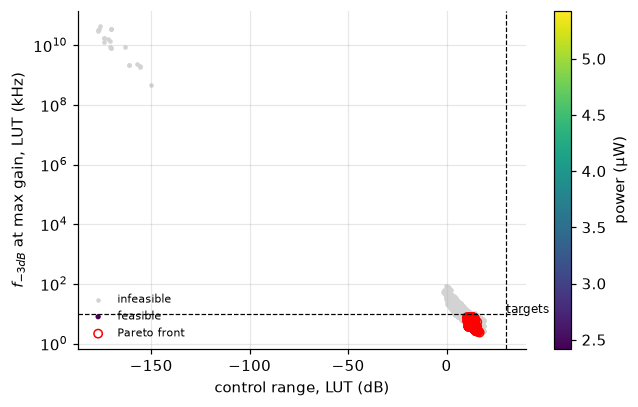

In [16]:
#@ DESIGN #@ FIG
SWEEP_PATH = nu.CACHE / "sweep.csv"
if RERUN_SWEEP:
    df = ev.sweep(LUT_PATH, dict(BASE)); df.to_csv(SWEEP_PATH, index=False)
df = pd.read_csv(SWEEP_PATH)
df["feasible"] = df["ok"] & (df["vds_min"] >= ev.VDS_MIN_LUT) & (df["i_tot"] <= ev.I_TOT_MAX) & (df["vov_in"] <= 0)
feas = df[df["feasible"]]
front = ev.pareto(df)
print(f"{len(df)} candidates | solved {int(df['ok'].sum())} | feasible {len(feas)} | Pareto-optimal {len(front)}")
print(f"largest LUT-predicted control range among feasible designs: {feas['range_db'].max():.2f} dB")
print(f"feasible designs with max-gain bandwidth >= 10 kHz: {(feas['f3db_hi'] >= 10e3).sum()}")

fig, ax = plt.subplots()
ax.scatter(df.loc[~df["feasible"] & df["ok"], "range_db"], df.loc[~df["feasible"] & df["ok"], "f3db_hi"]/1e3,
           s=4, c="lightgray", label="infeasible")
sc = ax.scatter(feas["range_db"], feas["f3db_hi"]/1e3, s=6, c=feas["power"]*1e6, cmap="viridis", label="feasible")
ax.scatter(front["range_db"], front["f3db_hi"]/1e3, s=30, facecolors="none", edgecolors="red", label="Pareto front")
ax.axhline(10, ls="--", c="k", lw=0.8); ax.axvline(30, ls="--", c="k", lw=0.8)
ax.text(30.3, 10.5, "targets", fontsize=8)
ax.set_xlabel("control range, LUT (dB)"); ax.set_ylabel(r"$f_{-3dB}$ at max gain, LUT (kHz)")
ax.set_yscale("log"); plt.colorbar(sc, label="power (µW)"); ax.legend(fontsize=7, loc="lower left")
fig.tight_layout(); fig.savefig(nu.FIGS / "design_space.png"); plt.show()
R = nu.record(n_candidates=len(df), n_feasible=len(feas), n_pareto=len(front),
              lut_best_range_db=float(feas["range_db"].max()), n_feasible_bw10k=int((feas["f3db_hi"] >= 10e3).sum()))

*Figure 4. Every candidate's LUT-predicted control range against bandwidth at maximum gain (log scale),
coloured by power; red rings mark the Pareto front.* The empty upper-right region is the result: within
this topology, control range and bandwidth trade directly against each other through $R_{out}$. No
candidate is predicted to approach the 30 dB range target. The LUT predicts none reaches 10 kHz at
maximum gain; §7.1 shows its bandwidth predictions are off by tens of percent away from the calibration
width, in both directions, so the SPICE check decides.

### 7.1 SPICE confirmation of the front, and the two picks
Sixteen or so designs are re-simulated in SPICE — gain, $R_{out}$ and headroom at both endpoints,
bandwidth with $C_L$, and integrated input noise at maximum gain: the best LUT candidates for each pick
below, plus designs spread along the front. This measures the flow's accuracy across the design space,
not just at the point it was calibrated on.

The targets conflict — range, bandwidth and noise cannot all be met — so the flow does not return one
"optimal" design. It returns the front, and two named picks from it, both chosen mechanically from the
SPICE results among designs with at least 150 mV of headroom on every constrained device and
$I_{tot} \le 5$ µA:

- **Flow-R (range):** the largest SPICE-measured control range.
- **Flow-S (speed and noise):** the highest bandwidth at maximum gain among designs that give up at most
  `RANGE_TOL_DB` = 2 dB of the hand-sized baseline's control range; designs within 3 % of that bandwidth
  are tie-broken by lowest integrated input noise. The 2 dB tolerance is a designer's choice; Table 10
  lists every alternative that was checked.

A fourth reference, the **baseline at flow tail bias**, is the hand-sized geometry run at Flow-S's tail
bias (everything else unchanged). It separates what comes from sizing from what comes simply from
spending more supply current.

In [17]:
#@ VERIFY
RANGE_TOL_DB = 2.0       # Flow-S may give up this much control range relative to the hand-sized baseline
base_lut = ev.evaluate_design(LUT, BASE)
by_bw    = feas[feas["range_db"] >= base_lut["range_db"] - RANGE_TOL_DB].sort_values("f3db_hi", ascending=False).head(6)
by_range = feas.sort_values("range_db", ascending=False).head(4)
spread   = front.sort_values("f3db_hi").iloc[np.unique(np.linspace(0, len(front)-1, 6).astype(int))]
pick = pd.concat([by_bw, by_range, spread]).drop_duplicates(subset=list(ev.SPACE))
DESIGN_KEYS = list(ev.SPACE)
def _spice_front():
    out = []
    for _, row in pick.iterrows():
        p = dict(BASE, **{k: row[k] for k in DESIGN_KEYS})
        a, b = vf.characterise(p, 0.0), vf.characterise(p, 0.3)
        bw = vf.bandwidth(p, 0.3, CL); nz = vf.noise(p, 0.3, *BAND)
        vmin = min(r[f"{m}_vds"] for r in (a, b) for m in ("m2", "m5", "m6", "m9"))
        out.append(dict(p=p, lut=row.to_dict(), av_lo_db=a["av_db"], av_hi_db=b["av_db"], rout_hi=b["rout"],
                        f3db_hi=bw["f3db"], vrms_hi=nz["vrms"], vds_min=vmin, i_tot=a["i_tot"]))
    return out
FR = nu.cached("front_spice", _spice_front, RERUN_SPICE)

# ---- the two picks, chosen mechanically from the SPICE results
ok = [f for f in FR if f["vds_min"] >= ev.HEADROOM_SPICE and f["i_tot"] <= 5e-6]
assert ok, "no SPICE-feasible design among those checked"
rng = lambda f: f["av_hi_db"] - f["av_lo_db"]
FLOW_R = max(ok, key=rng)
pool = [f for f in ok if rng(f) >= R["base_range_db"] - RANGE_TOL_DB] or ok
bw_best = max(f["f3db_hi"] for f in pool)
FLOW_S = min([f for f in pool if f["f3db_hi"] >= 0.97*bw_best], key=lambda f: f["vrms_hi"])

rows, e_av, e_ro = [], [], []
for i, f in enumerate(FR):
    l, p = f["lut"], f["p"]
    e_av += [l["av_lo_db"]-f["av_lo_db"], l["av_hi_db"]-f["av_hi_db"]]; e_ro.append(100*(l["rout_hi"]/f["rout_hi"]-1))
    tag = ("S" if f is FLOW_S else "") + ("R" if f is FLOW_R else "")
    rows.append([i, tag, f"{p['W_in']:g}/{p['L_in']:g}", f"{p['W_st']:g}/{p['L_st']:g}", f"{p['W_mir']:g}/{p['L_mir']:g}",
                 f"{p['vctrl_cm']:.2f}", f"{p['vbias']:.2f}",
                 f"{l['range_db']:.2f} / {rng(f):.2f}",
                 f"{l['f3db_hi']/1e3:.2f} / {f['f3db_hi']/1e3:.2f}",
                 f"{1e3*f['vds_min']:.0f}", f"{1e6*f['i_tot']:.2f}", f"{1e6*f['vrms_hi']:.1f}"])
nu.show_md("*Table 10. Pareto designs re-simulated in SPICE (tt, 27 °C). Cells show LUT / SPICE.* "
           "S and R mark the Flow-S and Flow-R picks. W/L in µm; noise is integrated 20 Hz–20 kHz, "
           "input-referred, at maximum gain.\n\n" +
           nu.md_table(["#", "pick", "M2,3 W/L", "M6–9 W/L", "M1,4 W/L", "V_ctrl,cm", "V_bias", "range (dB)",
                        "f_-3dB max gain (kHz)", "min V_DS (mV)", "I_tot (µA)", "noise (µV)"], rows))
print(f"evaluator error across the front: gain max |err| {max(map(abs, e_av)):.2f} dB, "
      f"R_out(max gain) max |err| {max(map(abs, e_ro)):.1f} %")
for nm, f in (("Flow-S", FLOW_S), ("Flow-R", FLOW_R)):
    print(nm, ":", {k: f["p"][k] for k in DESIGN_KEYS})
ws = [f["p"][k] for f in FR for k in ("W_in", "W_st", "W_mir")]
R = nu.record(front_err_av_db=max(map(abs, e_av)), front_err_rout_pct=max(map(abs, e_ro)), n_front_spice=len(FR),
              front_wmin=min(ws), front_wmax=max(ws),
              selS_params={k: FLOW_S["p"][k] for k in DESIGN_KEYS}, selR_params={k: FLOW_R["p"][k] for k in DESIGN_KEYS})

*Table 10. Pareto designs re-simulated in SPICE (tt, 27 °C). Cells show LUT / SPICE.* S and R mark the Flow-S and Flow-R picks. W/L in µm; noise is integrated 20 Hz–20 kHz, input-referred, at maximum gain.

| # | pick | M2,3 W/L | M6–9 W/L | M1,4 W/L | V_ctrl,cm | V_bias | range (dB) | f_-3dB max gain (kHz) | min V_DS (mV) | I_tot (µA) | noise (µV) |
|:--|:--:|:--:|:--:|:--:|:--:|:--:|:--:|:--:|:--:|:--:|:--:|
| 0 |  | 40/1 | 2.5/1 | 10/1 | 1.20 | 0.63 | 12.18 / 12.28 | 7.65 / 8.95 | 168 | 3.01 | 20.9 |
| 1 | S | 80/2 | 2.5/1 | 10/1 | 1.20 | 0.63 | 12.26 / 12.50 | 7.60 / 8.71 | 157 | 3.01 | 14.8 |
| 2 |  | 20/1 | 2.5/1 | 10/1 | 1.20 | 0.63 | 12.25 / 12.36 | 7.54 / 8.80 | 174 | 3.00 | 27.0 |
| 3 |  | 80/1 | 10/1 | 10/1 | 1.15 | 0.63 | 13.70 / 12.08 | 7.52 / 8.42 | 155 | 3.02 | 16.7 |
| 4 |  | 40/2 | 2.5/1 | 10/1 | 1.20 | 0.63 | 12.32 / 12.53 | 7.49 / 8.62 | 174 | 3.00 | 17.4 |
| 5 |  | 40/1 | 10/1 | 10/1 | 1.15 | 0.63 | 13.73 / 12.12 | 7.45 / 8.33 | 156 | 3.01 | 20.9 |
| 6 |  | 10/2 | 10/1 | 5/2 | 1.05 | 0.59 | 16.82 / 15.78 | 2.33 / 2.28 | 161 | 1.35 | 28.2 |
| 7 |  | 10/2 | 10/1 | 10/2 | 1.10 | 0.59 | 16.16 / 17.30 | 2.54 / 1.87 | 156 | 1.35 | 27.6 |
| 8 | R | 20/2 | 10/1 | 10/2 | 1.10 | 0.59 | 16.07 / 17.31 | 2.58 / 1.88 | 156 | 1.35 | 21.5 |
| 9 |  | 10/1 | 10/1 | 10/2 | 1.10 | 0.59 | 15.99 / 17.15 | 2.60 / 1.91 | 156 | 1.35 | 36.6 |
| 10 |  | 10/2 | 5/1 | 10/1 | 1.10 | 0.59 | 12.92 / 12.20 | 3.49 / 3.91 | 175 | 1.35 | 29.0 |
| 11 |  | 80/1 | 2.5/1 | 10/1 | 1.20 | 0.59 | 12.48 / 12.24 | 3.68 / 4.22 | 150 | 1.37 | 18.2 |
| 12 |  | 20/2 | 10/1 | 10/1 | 1.15 | 0.61 | 13.77 / 12.12 | 5.12 / 5.69 | 165 | 2.03 | 22.2 |
| 13 |  | 10/1 | 5/2 | 5/1 | 1.10 | 0.63 | 12.12 / 12.20 | 6.62 / 6.51 | 154 | 2.98 | 36.9 |
| 14 |  | 80/1 | 5/2 | 10/1 | 1.20 | 0.63 | 11.46 / 10.77 | 7.71 / 8.63 | 158 | 3.02 | 16.7 |

evaluator error across the front: gain max |err| 2.71 dB, R_out(max gain) max |err| 26.1 %
Flow-S : {'W_in': 80.0, 'L_in': 2.0, 'W_st': 2.5, 'L_st': 1.0, 'W_mir': 10.0, 'L_mir': 1.0, 'vctrl_cm': 1.2, 'vbias': 0.63}
Flow-R : {'W_in': 20.0, 'L_in': 2.0, 'W_st': 10.0, 'L_st': 1.0, 'W_mir': 10.0, 'L_mir': 2.0, 'vctrl_cm': 1.1, 'vbias': 0.59}


---
## 8. Verification: the baseline and the flow's picks

Four designs are characterised identically: the hand-sized baseline, the baseline at the flow's tail bias
(to separate bias from sizing), and the two picks. For each: gain curve, bandwidth with $C_L$ = 1 pF,
input-referred noise, and output swing at THD ≤ 1 % (1 kHz sine; harmonics 1–5 are fitted over the last
8 of 12 periods with the slow settling of the mirror node removed, and the swing is interpolated at the
1 % crossing). The two picks are also run across process and temperature corners.

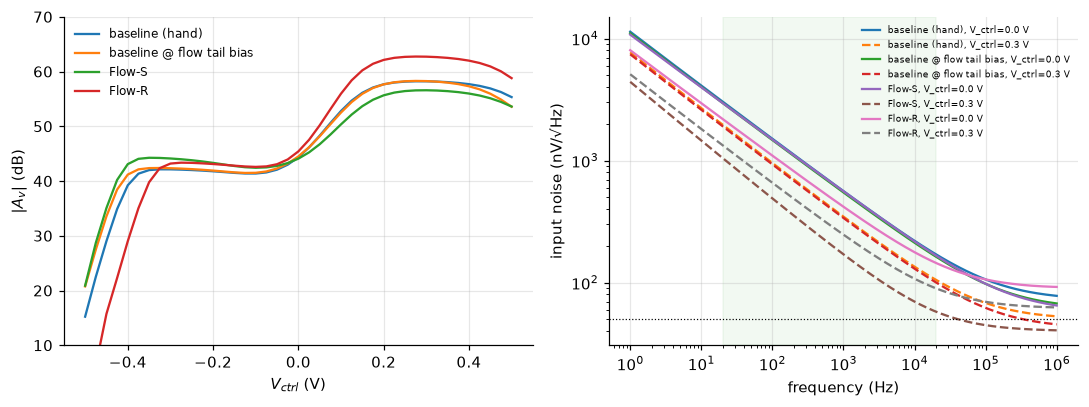

In [18]:
#@ VERIFY #@ FIG
DES = {"baseline": dict(BASE),
       "base_fb":  dict(BASE, vbias=FLOW_S["p"]["vbias"]),
       "flow_S":   dict(FLOW_S["p"]),
       "flow_R":   dict(FLOW_R["p"])}
LABEL = {"baseline": "baseline (hand)", "base_fb": "baseline @ flow tail bias", "flow_S": "Flow-S", "flow_R": "Flow-R"}
def _verify():
    out = {}
    for name, p in DES.items():
        a, b = vf.characterise(p, 0.0), vf.characterise(p, 0.3)
        gc = vf.gain_curve(p, VGRID)
        bw = {f"{v:.1f}": vf.bandwidth(p, v, CL) for v in (0.0, 0.3)}
        nz = {f"{v:.1f}": vf.noise(p, v, *BAND) for v in (0.0, 0.3)}
        sw = {f"{v:.1f}": vf.swing_at_thd(p, v, r["av"]) for v, r in ((0.0, a), (0.3, b))}
        out[name] = dict(op={"0.0": a, "0.3": b}, gain_curve=gc, bw=bw, noise=nz, swing=sw)
    return out
V = nu.cached("verify", _verify, RERUN_SPICE)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))
for name, v in V.items():
    a_db = 20*np.log10(np.array(v["gain_curve"]))
    axs[0].plot(VGRID, a_db, label=LABEL[name])
    for ve, ls in (("0.0", "-"), ("0.3", "--")):
        n = v["noise"][ve]; axs[1].loglog(n["f"], 1e9*np.array(n["vn"]), ls, label=f"{LABEL[name]}, V_ctrl={ve} V")
axs[0].set_xlabel(r"$V_{ctrl}$ (V)"); axs[0].set_ylabel(r"$|A_v|$ (dB)"); axs[0].set_ylim(10, 70); axs[0].legend(fontsize=8)
axs[1].axhline(50, c="k", lw=0.8, ls=":"); axs[1].axvspan(*BAND, color="C2", alpha=0.06)
axs[1].set_xlabel("frequency (Hz)"); axs[1].set_ylabel("input noise (nV/√Hz)"); axs[1].legend(fontsize=6)
fig.tight_layout(); fig.savefig(nu.FIGS / "verify_gain_noise.png"); plt.show()

summ = {}
for name, v in V.items():
    a_db = 20*np.log10(np.array(v["gain_curve"])); lo, hi = monotonic_span(VGRID, a_db)
    op0, op3 = v["op"]["0.0"], v["op"]["0.3"]
    vmin = min(r[f"{m}_vds"] for r in (op0, op3) for m in ("m2", "m5", "m6", "m9"))
    s = dict(av_lo_db=op0["av_db"], av_hi_db=op3["av_db"], range_db=op3["av_db"]-op0["av_db"],
             mono_range_db=float(a_db[hi]-a_db[lo]), mono_lo_v=float(VGRID[lo]), mono_hi_v=float(VGRID[hi]),
             i_tot=op0["i_tot"], power=op0["power"], vds_min=vmin,
             f3db_lo=v["bw"]["0.0"]["f3db"], f3db_hi=v["bw"]["0.3"]["f3db"],
             vn1k_lo=v["noise"]["0.0"]["vn_1k"], vn1k_hi=v["noise"]["0.3"]["vn_1k"],
             vrms_lo=v["noise"]["0.0"]["vrms"], vrms_hi=v["noise"]["0.3"]["vrms"],
             swing_lo=v["swing"]["0.0"]["vout_pk_max"], swing_hi=v["swing"]["0.3"]["vout_pk_max"])
    s["nef_lo"], s["nef_hi"] = vf.nef(s["vrms_lo"], s["i_tot"], BAND[1]-BAND[0]), vf.nef(s["vrms_hi"], s["i_tot"], BAND[1]-BAND[0])
    dr = lambda sw, av, vr: 20*math.log10((sw/av/math.sqrt(2))/vr) if sw > 0 else float("nan")
    s["dr_hi_db"] = dr(s["swing_hi"], op3["av"], s["vrms_hi"])   # input-referred dynamic range, max gain
    s["dr_lo_db"] = dr(s["swing_lo"], op0["av"], s["vrms_lo"])
    summ[name] = s
R = nu.record(**{k: v for k, v in summ.items()})

*Figure 5. (a) Gain-control characteristic of the hand-sized baseline, the baseline at the flow's tail bias, and
the two picks. (b) Input-referred noise density at both control endpoints; the dotted line is the
50 nV/√Hz target and the shaded band is 20 Hz–20 kHz.* The noise density falls with frequency across the
audio band, the signature of flicker noise, and the integrated noise is set mostly at low frequency.

In [19]:
#@ VERIFY
CORNERS = [("tt", 27), ("ss", 27), ("ff", 27), ("tt", -20), ("tt", 85)]
PICKS = {"flow_S": "Flow-S", "flow_R": "Flow-R"}
def _corners():
    return {k: {f"{c}/{t}": {f"{v:.1f}": vf.characterise(dict(DES[k], corner=c, temp=t), v) for v in (0.0, 0.3)}
                for c, t in CORNERS} for k in PICKS}
CR = nu.cached("corners_picks", _corners, RERUN_SPICE)
rows, cfail = [], []
for k, nm in PICKS.items():
    for cname, r in CR[k].items():
        a, b = r["0.0"], r["0.3"]
        vmin = min(x[f"{m}_vds"] for x in (a, b) for m in ("m2", "m5", "m6", "m9"))
        itot = max(a["i_tot"], b["i_tot"])
        ok_h, ok_i = vmin >= 0.13, itot <= 5e-6
        if not (ok_h and ok_i):
            cfail.append(f"{nm} at {cname}: " + " and ".join(w for w, g in (("headroom", ok_h), ("supply current", ok_i)) if not g))
        rows.append([nm, cname, f"{1e6*itot:.2f}", f"{a['av_db']:.1f}", f"{b['av_db']:.1f}", f"{b['av_db']-a['av_db']:.1f}",
                     f"{1/(2*math.pi*b['rout']*CL)/1e3:.1f}", f"{1e3*vmin:.0f}", "✅" if ok_h else "❌", "✅" if ok_i else "❌"])
nu.show_md("*Table 11. The two picks across process and temperature (1.8 V). Bandwidth is the dominant-pole "
           "value $1/(2\\pi R_{out} C_L)$, which matches the full `.ac` result to within a few percent at tt.*\n\n" +
           nu.md_table(["design", "corner/°C", "I_tot (µA)", "A_v @0 V (dB)", "A_v @0.3 V (dB)", "range (dB)",
                        "f_-3dB max gain (kHz)", "min V_DS (mV)", "headroom ≥ 130 mV", "I_tot ≤ 5 µA"], rows))
nu.show_md("**Corner check against the budget** (generated): " +
           ("; ".join(cfail) + "." if cfail else "every corner meets the headroom and supply-current limits."))
R = nu.record(corner_fail=cfail,
              corner_itot_max={nm: max(max(x["i_tot"] for x in r.values()) for r in CR[k].values()) for k, nm in PICKS.items()})

*Table 11. The two picks across process and temperature (1.8 V). Bandwidth is the dominant-pole value $1/(2\pi R_{out} C_L)$, which matches the full `.ac` result to within a few percent at tt.*

| design | corner/°C | I_tot (µA) | A_v @0 V (dB) | A_v @0.3 V (dB) | range (dB) | f_-3dB max gain (kHz) | min V_DS (mV) | headroom ≥ 130 mV | I_tot ≤ 5 µA |
|:--|:--:|:--:|:--:|:--:|:--:|:--:|:--:|:--:|:--:|
| Flow-S | tt/27 | 3.01 | 44.1 | 56.6 | 12.5 | 8.8 | 157 | ✅ | ✅ |
| Flow-S | ss/27 | 1.96 | 43.9 | 56.6 | 12.7 | 5.7 | 156 | ✅ | ✅ |
| Flow-S | ff/27 | 4.56 | 44.2 | 56.5 | 12.3 | 13.5 | 158 | ✅ | ✅ |
| Flow-S | tt/-20 | 1.60 | 43.8 | 57.2 | 13.4 | 5.1 | 125 | ❌ | ✅ |
| Flow-S | tt/85 | 5.11 | 44.0 | 55.1 | 11.1 | 14.8 | 138 | ✅ | ❌ |
| Flow-R | tt/27 | 1.35 | 45.4 | 62.7 | 17.3 | 1.9 | 156 | ✅ | ✅ |
| Flow-R | ss/27 | 0.85 | 45.3 | 62.4 | 17.1 | 1.3 | 157 | ✅ | ✅ |
| Flow-R | ff/27 | 2.13 | 45.5 | 63.0 | 17.5 | 2.9 | 153 | ✅ | ✅ |
| Flow-R | tt/-20 | 0.61 | 45.3 | 62.8 | 17.5 | 1.0 | 125 | ❌ | ✅ |
| Flow-R | tt/85 | 2.68 | 45.4 | 61.8 | 16.4 | 3.5 | 179 | ✅ | ✅ |

**Corner check against the budget** (generated): Flow-S at tt/-20: headroom; Flow-S at tt/85: supply current; Flow-R at tt/-20: headroom.

The tail is biased by a fixed gate voltage, so in weak inversion the supply current — and with it every
gain figure — moves exponentially with threshold voltage and temperature. A production design would
derive $V_{bias}$ from a current reference; that is listed as future work rather than claimed.

---
## 9. Results against the specification

In [20]:
#@ FIG
cols = ["baseline", "flow_S", "flow_R"]
uV, nV = (lambda x: f"{1e6*x:.1f} µV"), (lambda x: f"{1e9*x:.0f} nV/√Hz")
mv = lambda x: f"{1e3*x:.0f} mV pk" if x > 0 else "< 2 mV pk"
db_ = lambda x: f"{x:.1f} dB" if x == x else "—"
SPEC = [("Supply current", "≤ 5 µA", "i_tot", lambda x: f"{1e6*x:.2f} µA", lambda x: x <= 5e-6),
        ("Power", "—", "power", lambda x: f"{1e6*x:.2f} µW", None),
        ("Control range, 0 → 0.3 V", "≥ 30 dB", "range_db", lambda x: f"{x:.2f} dB", lambda x: x >= 30),
        ("Monotonic control range", "≥ 30 dB", "mono_range_db", lambda x: f"{x:.2f} dB", lambda x: x >= 30),
        ("f-3dB, min gain (C_L 1 pF)", "≥ 10 kHz", "f3db_lo", lambda x: f"{x/1e3:.2f} kHz", lambda x: x >= 10e3),
        ("f-3dB, max gain (C_L 1 pF)", "≥ 10 kHz", "f3db_hi", lambda x: f"{x/1e3:.2f} kHz", lambda x: x >= 10e3),
        ("Noise @1 kHz, min gain", "≤ 50 nV/√Hz", "vn1k_lo", nV, lambda x: x <= 50e-9),
        ("Noise @1 kHz, max gain", "≤ 50 nV/√Hz", "vn1k_hi", nV, lambda x: x <= 50e-9),
        ("Integrated noise, min gain", "≤ 7 µV", "vrms_lo", uV, lambda x: x <= 7e-6),
        ("Integrated noise, max gain", "≤ 7 µV", "vrms_hi", uV, lambda x: x <= 7e-6),
        ("NEF, max gain", "≤ 5", "nef_hi", lambda x: f"{x:.1f}", lambda x: x <= 5),
        ("Output swing at THD ≤ 1 %, min gain", "report", "swing_lo", mv, None),
        ("Output swing at THD ≤ 1 %, max gain", "report", "swing_hi", mv, None),
        ("Input dynamic range, max gain", "report", "dr_hi_db", db_, None),
        ("Min device V_DS, both endpoints", "≥ 130 mV", "vds_min", lambda x: f"{1e3*x:.0f} mV", lambda x: x >= 0.13)]
mark = lambda ok, x: "—" if ok is None else ("✅" if ok(x) else "❌")
T = [[name, tgt] + [f(summ[c][key]) for c in cols] + [mark(ok, summ[c][key]) for c in cols if c != "baseline"]
     for name, tgt, key, f, ok in SPEC]
hdr = ["Parameter", "Target", "Baseline (hand)", "Flow-S", "Flow-R", "Met S", "Met R"]
nu.show_md("*Table 12. Specification compliance (tt, 27 °C, 1.8 V, schematic level).*\n\n" + nu.md_table(hdr, T))

CAUSE = {"range_db": "control range is bounded by the topology's gain floor (§3.4, §4.2), not by sizing — no swept design approaches 30 dB (§7)",
         "mono_range_db": None,
         "f3db_hi": "gain and bandwidth share $R_{out}$, so the maximum-gain setting is the narrowest-band one",
         "f3db_lo": "the minimum-gain setting is limited by the same $R_{out}$–$C_L$ pole",
         "vn1k_hi": "flicker-dominated input noise (Figure 5b); flicker voltage falls only as $1/\\sqrt{WL}$, so the target needs input-device area far beyond this core, or chopping",
         "vn1k_lo": None, "vrms_lo": None, "vrms_hi": None, "nef_hi": None,
         "i_tot": "tail current exceeds the budget", "vds_min": "a constrained device is below 130 mV of headroom"}
picks_ = ("flow_S", "flow_R")
fails = [key for name, tgt, key, f, ok in SPEC if ok and any(not ok(summ[c][key]) for c in picks_)]
txt = [f"- *{next(n for n, t, k, f, o in SPEC if k == key)}:* {CAUSE[key]}" for key in fails if CAUSE.get(key)]
nu.show_md("**Diagnosed causes of the misses** (generated from Table 12; a miss by either pick is listed):\n\n" +
           ("\n".join(txt) if txt else "- none"))

# ---- picks versus the hand-sized baseline: computed, so the wording can never contradict the numbers
cmp_, dom, lines = {}, [], []
for c, nm in (("flow_S", "Flow-S"), ("flow_R", "Flow-R")):
    better, worse = nu.compare(summ[c], summ["baseline"])
    cmp_[c] = dict(better=better, worse=worse)
    lines.append(f"- **{nm}** is better than the hand-sized baseline on {len(better)} metrics ({', '.join(better) or 'none'}) "
                 f"and worse on {len(worse)} ({', '.join(worse) or 'none'}).")
    if better and not worse: dom.append(nm)
tail = (f"{' and '.join(dom)} {'dominate' if len(dom) > 1 else 'dominates'} the baseline on every compared metric." if dom
        else "Neither pick dominates the baseline: each trades some metrics for others.")
nu.show_md("**Flow picks versus the hand-sized baseline** (generated; changes under 3 % are not counted):\n\n" +
           "\n".join(lines) + "\n\n" + tail)

# ---- bias versus sizing
fm = [("Control range", "range_db", lambda x: f"{x:.2f} dB"), ("f-3dB at max gain", "f3db_hi", lambda x: f"{x/1e3:.2f} kHz"),
      ("Integrated noise at max gain", "vrms_hi", uV), ("Supply current", "i_tot", lambda x: f"{1e6*x:.2f} µA")]
nu.show_md("*Table 12b. Bias versus sizing: the hand-sized geometry at the flow's tail bias separates what comes from "
           "spending more supply current from what comes from the new device sizes.*\n\n" +
           nu.md_table(["Metric", "Baseline (hand)", "Baseline @ flow tail bias", "Flow-S"],
                       [[nm] + [f(summ[c][key]) for c in ("baseline", "base_fb", "flow_S")] for nm, key, f in fm]))

# ---- device sizes: the input to layout
P = {c: DES[c] for c in cols}
sz = lambda p, w, l: f"{p[w]:g} / {p[l]:g}"
SIZES = [["M2, M3 (input pair)"] + [sz(P[c], "W_in", "L_in") for c in cols],
         ["M6–M9 (steering)"] + [sz(P[c], "W_st", "L_st") for c in cols],
         ["M1, M4 (PMOS mirror)"] + [sz(P[c], "W_mir", "L_mir") for c in cols],
         ["M5 (tail)"] + [sz(P[c], "W_tail", "L_tail") for c in cols],
         ["V_bias (V)"] + [f"{P[c]['vbias']:.2f}" for c in cols],
         ["steering common mode (V)"] + [f"{P[c]['vctrl_cm']:.2f}" for c in cols]]
nu.show_md("*Table 12c. Device sizes (W / L in µm) and bias — the input to layout. The layout target is Flow-S.*\n\n" +
           nu.md_table(["Device group", "Baseline (hand)", "Flow-S", "Flow-R"], SIZES))
R = nu.record(spec_header=hdr, spec_table=T, size_table=SIZES, cmp=cmp_,
              n_targets=sum(1 for _, _, _, _, o in SPEC if o),
              met_S=sum(1 for _, _, k, _, o in SPEC if o and o(summ["flow_S"][k])),
              met_R=sum(1 for _, _, k, _, o in SPEC if o and o(summ["flow_R"][k])),
              misses_S=[n for n, t, k, f, o in SPEC if o and not o(summ["flow_S"][k])],
              misses_R=[n for n, t, k, f, o in SPEC if o and not o(summ["flow_R"][k])])

*Table 12. Specification compliance (tt, 27 °C, 1.8 V, schematic level).*

| Parameter | Target | Baseline (hand) | Flow-S | Flow-R | Met S | Met R |
|:--|:--:|:--:|:--:|:--:|:--:|:--:|
| Supply current | ≤ 5 µA | 2.04 µA | 3.01 µA | 1.35 µA | ✅ | ✅ |
| Power | — | 3.67 µW | 5.43 µW | 2.44 µW | — | — |
| Control range, 0 → 0.3 V | ≥ 30 dB | 13.87 dB | 12.50 dB | 17.31 dB | ❌ | ❌ |
| Monotonic control range | ≥ 30 dB | 16.85 dB | 14.16 dB | 20.16 dB | ❌ | ❌ |
| f-3dB, min gain (C_L 1 pF) | ≥ 10 kHz | 11.00 kHz | 17.26 kHz | 6.38 kHz | ✅ | ❌ |
| f-3dB, max gain (C_L 1 pF) | ≥ 10 kHz | 4.82 kHz | 8.71 kHz | 1.88 kHz | ❌ | ❌ |
| Noise @1 kHz, min gain | ≤ 50 nV/√Hz | 563 nV/√Hz | 560 nV/√Hz | 419 nV/√Hz | ❌ | ❌ |
| Noise @1 kHz, max gain | ≤ 50 nV/√Hz | 348 nV/√Hz | 171 nV/√Hz | 247 nV/√Hz | ❌ | ❌ |
| Integrated noise, min gain | ≤ 7 µV | 46.9 µV | 46.4 µV | 35.9 µV | ❌ | ❌ |
| Integrated noise, max gain | ≤ 7 µV | 29.1 µV | 14.8 µV | 21.5 µV | ❌ | ❌ |
| NEF, max gain | ≤ 5 | 11.3 | 7.0 | 6.8 | ❌ | ❌ |
| Output swing at THD ≤ 1 %, min gain | report | 34 mV pk | 20 mV pk | 24 mV pk | — | — |
| Output swing at THD ≤ 1 %, max gain | report | 54 mV pk | 38 mV pk | 37 mV pk | — | — |
| Input dynamic range, max gain | report | 4.1 dB | 8.6 dB | -1.0 dB | — | — |
| Min device V_DS, both endpoints | ≥ 130 mV | 165 mV | 157 mV | 156 mV | ✅ | ✅ |

**Diagnosed causes of the misses** (generated from Table 12; a miss by either pick is listed):

- *Control range, 0 → 0.3 V:* control range is bounded by the topology's gain floor (§3.4, §4.2), not by sizing — no swept design approaches 30 dB (§7)
- *f-3dB, min gain (C_L 1 pF):* the minimum-gain setting is limited by the same $R_{out}$–$C_L$ pole
- *f-3dB, max gain (C_L 1 pF):* gain and bandwidth share $R_{out}$, so the maximum-gain setting is the narrowest-band one
- *Noise @1 kHz, max gain:* flicker-dominated input noise (Figure 5b); flicker voltage falls only as $1/\sqrt{WL}$, so the target needs input-device area far beyond this core, or chopping

**Flow picks versus the hand-sized baseline** (generated; changes under 3 % are not counted):

- **Flow-S** is better than the hand-sized baseline on 4 metrics (bandwidth at min gain, bandwidth at max gain, integrated noise at max gain, NEF at max gain) and worse on 4 (control range, monotonic control range, supply power, output swing at max gain).
- **Flow-R** is better than the hand-sized baseline on 6 metrics (control range, monotonic control range, integrated noise at min gain, integrated noise at max gain, NEF at max gain, supply power) and worse on 3 (bandwidth at min gain, bandwidth at max gain, output swing at max gain).

Neither pick dominates the baseline: each trades some metrics for others.

*Table 12b. Bias versus sizing: the hand-sized geometry at the flow's tail bias separates what comes from spending more supply current from what comes from the new device sizes.*

| Metric | Baseline (hand) | Baseline @ flow tail bias | Flow-S |
|:--|:--:|:--:|:--:|
| Control range | 13.87 dB | 13.77 dB | 12.50 dB |
| f-3dB at max gain | 4.82 kHz | 6.93 kHz | 8.71 kHz |
| Integrated noise at max gain | 29.1 µV | 28.3 µV | 14.8 µV |
| Supply current | 2.04 µA | 3.00 µA | 3.01 µA |

*Table 12c. Device sizes (W / L in µm) and bias — the input to layout. The layout target is Flow-S.*

| Device group | Baseline (hand) | Flow-S | Flow-R |
|:--|:--:|:--:|:--:|
| M2, M3 (input pair) | 20 / 1 | 80 / 2 | 20 / 2 |
| M6–M9 (steering) | 5 / 1 | 2.5 / 1 | 10 / 1 |
| M1, M4 (PMOS mirror) | 5 / 1 | 10 / 1 | 10 / 2 |
| M5 (tail) | 5 / 1 | 5 / 1 | 5 / 1 |
| V_bias (V) | 0.61 | 0.63 | 0.59 |
| steering common mode (V) | 1.15 | 1.20 | 1.10 |

Neither pick is "the answer". They are two points on a front the flow computed, each verified in SPICE, and
choosing between them is a system-level decision (gain range per stage versus the number of cascaded
stages). The hand-sized baseline is shown as a reference, not as a bar the flow must clear on every axis;
the generated comparison above says where each pick wins and where it loses.

### 9.1 Comparison with prior art
*Table 13.* ⟦FILL: 2–3 published hearing-aid / biomedical gain stages, with numbers copied from the papers
— never estimated. Rows: process, supply, current, gain range, noise, NEF, area, open source.⟧

| | This work (Flow-S / Flow-R) | ⟦Ref A⟧ | ⟦Ref B⟧ |
|:--|:--:|:--:|:--:|
| Process | SKY130 (open) | | |
| Open-source, re-fabricable | **Yes** | | |

---
## 10. Physical implementation

⟦FILL — keep exactly ONE of the two paragraphs below and delete the other.⟧

**(A — layout completed)** The Flow-S design (Table 12c) was laid out with ⟦gLayout / Magic⟧: common-centroid input
pair with dummies, matched steering pairs M6/M9 and M7/M8 (their equality is what makes the A and B
splits identical), matched mirror M1/M4, guard ring, symmetric routing of `vin_p/vin_n` and
`vctrl_p/vctrl_n`, and short symmetric `net4`/`v_out` routes (`v_out` is a multi-MΩ node, so every
femtofarad there moves the pole). The DRC and LVS reports are printed by the cell below.

**(B — layout not included)** Physical layout is not part of this submission. The topology, matching
plan (common-centroid input pair with dummies, matched M6/M9, M7/M8 and M1/M4, guard ring, symmetric
routing of the differential and control nets, minimal `v_out` capacitance) and the parametrised device
list are fixed, and layout is the first item of future work (§11.3).

In [21]:
#@ LAYOUT
LAY = Path("layout")
drc, lvs = LAY / "drc_report.txt", LAY / "lvs_report.txt"
if drc.exists() and lvs.exists():
    print("---- DRC ----"); print(drc.read_text()[-1500:])
    print("---- LVS ----"); print(lvs.read_text()[-1500:])
else:
    print("No layout reports in ./layout - physical implementation not included (see §10, paragraph B).")

No layout reports in ./layout - physical implementation not included (see §10, paragraph B).


---
## 11. Discussion

### 11.1 Limitations
1. **Topology-bounded control range.** The gain floor (§3.4) is structural; no single-stage sizing of this
   core reaches 30 dB.
2. **Gain–bandwidth coupling** through the shared $R_{out}$ (§9).
3. **Flicker noise and dynamic range** fall well short of hearing-aid requirements (Table 12).
4. **Voltage-mode bias** makes current and gain exponentially PVT-sensitive (Table 11).
5. **LUT scope.** The table is characterised at tt, 27 °C; corners are verified in SPICE only. Width
   scaling from the 5 µm reference introduces a tail-voltage error (Table 7) because SKY130 models are
   binned by width; it is covered by a 10 mV LUT margin plus a SPICE headroom re-check. The DC solve assumes $v_{id}=0$ symmetry (verified to < 0.1 mV in SPICE).
6. **The picks are chosen at one corner and one load.** Both are selected at tt, 27 °C with $C_L$ = 1 pF;
   Table 11 shows how supply current and bandwidth move across corners, and corner-aware selection is
   future work.
7. **Not measured:** mismatch / Monte Carlo, PSRR/CMRR (the single-ended output provides no supply or
   common-mode rejection), post-layout parasitics.

### 11.2 Scope: a gain core, not a compressor
The envelope detector and closed gain-control loop are outside this notebook. In a complete compressor
$V_{ctrl}$ would be driven by a rectifier and peak/RMS detector whose time constants set attack and
release, and that loop's stability would need its own verification. **No compression ratio, threshold,
knee or attack/release behaviour is claimed or should be inferred.**

### 11.3 Future work
1. Layout, LVS and post-layout re-verification of the Flow-S design (if §10 is paragraph B).
2. Lift the range ceiling: cascade two cores, or replace the mirror load with one whose bias is
   independent of $\alpha$; extend the evaluator to the new topology (the method carries over unchanged).
3. Add device width as a LUT axis, removing the width-binning error that dominates the evaluator's
   accuracy across the front; add flicker-noise data so noise becomes a first-class sweep objective.
4. Current-reference biasing, Monte Carlo, and corner-aware LUTs.

In [22]:
#@ FIG
# §12 summary text, TL;DR and README are generated here from cache/results.json - nothing is typed by hand.
R = nu.results(); b, S, Q = R["baseline"], R["flow_S"], R["flow_R"]
def desc(s):
    return (f"control range {s['range_db']:.1f} dB, max-gain bandwidth {s['f3db_hi']/1e3:.1f} kHz, "
            f"integrated input noise {1e6*s['vrms_hi']:.1f} µV, {1e6*s['power']:.2f} µW")
def vs(key):
    c = R["cmp"][key]
    return (f"better than the hand-sized baseline on {len(c['better'])} compared metrics ({', '.join(c['better']) or 'none'}), "
            f"worse on {len(c['worse'])} ({', '.join(c['worse']) or 'none'})")
dom = [n for n, k in (("Flow-S", "flow_S"), ("Flow-R", "flow_R")) if R["cmp"][k]["better"] and not R["cmp"][k]["worse"]]
dom_txt = ("; " + " and ".join(dom) + (" dominate the baseline" if len(dom) > 1 else " dominates the baseline")) if dom \
          else "; neither pick dominates the hand-sized baseline"
cell = lambda s, a, f, u: f"{f(s[a])} {u}".strip()
tldr = f'''### TL;DR
A **SPICE-validated $g_m/I_D$ lookup-table flow** for a nine-transistor subthreshold current-steering VGA core
in open SKY130. A LUT evaluator — KCL operating-point solve on interpolated device data with body effect,
plus a full small-signal nodal solve, no SPICE in the loop — predicts gain within **{R['eval_err_av_db']:.2f} dB**
and output resistance within **{R['eval_err_rout_pct']:.1f} %** at its calibration point, where the textbook estimate
misses by **{R['naive_err_db']:.1f} dB** and gets the direction of gain control wrong: the output device is a cascode
on a node the gain control itself modulates. Across {R['n_front_spice']} SPICE-checked designs spanning
{R['front_wmin']:g}–{R['front_wmax']:g} µm widths its error grows to {R['front_err_av_db']:.1f} dB (SKY130 width binning),
so the flow re-verifies every design it keeps in SPICE. It swept **{R['n_candidates']:,}** candidates under headroom,
current and bandwidth constraints and returns a Pareto front plus two SPICE-verified picks{dom_txt}:

- **Flow-S** (speed and noise): {desc(S)}; {vs('flow_S')}.
- **Flow-R** (range): {desc(Q)}; {vs('flow_R')}.
- **Hand-sized baseline:** {desc(b)}.

Flow-S meets {R['met_S']} of {R['n_targets']} graded targets and Flow-R {R['met_R']}. Every miss is traced to a mechanism
in §9: a structural gain floor, $R_{{out}}$-shared gain–bandwidth, and flicker noise.

| Evaluator accuracy | Value |
|:--|:--|
| Error vs SPICE at the calibration point (gain / $R_{{out}}$) | {R['eval_err_av_db']:.2f} dB / {R['eval_err_rout_pct']:.1f} % |
| Error across the SPICE-checked designs (gain / $R_{{out}}$) | {R['front_err_av_db']:.1f} dB / {R['front_err_rout_pct']:.0f} % |
| Textbook-estimate error (gain) | {R['naive_err_db']:.1f} dB |
| Candidates swept / feasible / Pareto | {R['n_candidates']:,} / {R['n_feasible']:,} / {R['n_pareto']} |

| Headline | Baseline (hand) | Flow-S | Flow-R |
|:--|:--:|:--:|:--:|
| Control range, 0–0.3 V / monotonic (dB) | {b['range_db']:.1f} / {b['mono_range_db']:.1f} | {S['range_db']:.1f} / {S['mono_range_db']:.1f} | {Q['range_db']:.1f} / {Q['mono_range_db']:.1f} |
| $f_{{-3dB}}$ min / max gain, $C_L$ = 1 pF (kHz) | {b['f3db_lo']/1e3:.1f} / {b['f3db_hi']/1e3:.1f} | {S['f3db_lo']/1e3:.1f} / {S['f3db_hi']/1e3:.1f} | {Q['f3db_lo']/1e3:.1f} / {Q['f3db_hi']/1e3:.1f} |
| Integrated input noise min / max gain (µV$_{{rms}}$) | {1e6*b['vrms_lo']:.1f} / {1e6*b['vrms_hi']:.1f} | {1e6*S['vrms_lo']:.1f} / {1e6*S['vrms_hi']:.1f} | {1e6*Q['vrms_lo']:.1f} / {1e6*Q['vrms_hi']:.1f} |
| Supply current (µA) / power (µW) | {1e6*b['i_tot']:.2f} / {1e6*b['power']:.2f} | {1e6*S['i_tot']:.2f} / {1e6*S['power']:.2f} | {1e6*Q['i_tot']:.2f} / {1e6*Q['power']:.2f} |
'''
nu.record(tldr_md=tldr)
nu.show_md(tldr)

# README (datasheet style) - generated, so it can never disagree with the notebook
readme = f'''# Subthreshold current-steering VGA core + SPICE-validated gm/ID LUT flow (SKY130)

IEEE SSCS Code-a-Chip, ISSCC 2027. Notebook: `notebook.ipynb`. License: Apache-2.0.

{tldr.replace("### TL;DR", "## Summary")}

## Specification compliance (tt, 27 °C, 1.8 V, schematic level)

''' + nu.md_table(R["spec_header"], R["spec_table"]) + '''

## Device sizes (W / L in µm) and bias

''' + nu.md_table(["Device group", "Baseline (hand)", "Flow-S", "Flow-R"], R["size_table"]) + '''

## Reproduce
* Tier 1 (Python only, < 1 min): `pip install numpy scipy pandas matplotlib jupyter`, open `notebook.ipynb`, Run All.
* Tier 2/3 (IIC-OSIC-TOOLS container): set `RERUN_SPICE`, `REBUILD_LUT`, `RERUN_SWEEP` to `True` in §2 and Run All,
  or run `python tools/run_nb.py --mode full`.

## Layout
`scripts/` holds all simulation logic; `cache/` the characterisation table, sweep and every simulation result;
`images/` every figure.
'''
Path("README.md").write_text(readme)
print("README.md written from cache/results.json")

### TL;DR
A **SPICE-validated $g_m/I_D$ lookup-table flow** for a nine-transistor subthreshold current-steering VGA core
in open SKY130. A LUT evaluator — KCL operating-point solve on interpolated device data with body effect,
plus a full small-signal nodal solve, no SPICE in the loop — predicts gain within **0.31 dB**
and output resistance within **1.2 %** at its calibration point, where the textbook estimate
misses by **22.9 dB** and gets the direction of gain control wrong: the output device is a cascode
on a node the gain control itself modulates. Across 15 SPICE-checked designs spanning
2.5–80 µm widths its error grows to 2.7 dB (SKY130 width binning),
so the flow re-verifies every design it keeps in SPICE. It swept **4,320** candidates under headroom,
current and bandwidth constraints and returns a Pareto front plus two SPICE-verified picks; neither pick dominates the hand-sized baseline:

- **Flow-S** (speed and noise): control range 12.5 dB, max-gain bandwidth 8.7 kHz, integrated input noise 14.8 µV, 5.43 µW; better than the hand-sized baseline on 4 compared metrics (bandwidth at min gain, bandwidth at max gain, integrated noise at max gain, NEF at max gain), worse on 4 (control range, monotonic control range, supply power, output swing at max gain).
- **Flow-R** (range): control range 17.3 dB, max-gain bandwidth 1.9 kHz, integrated input noise 21.5 µV, 2.44 µW; better than the hand-sized baseline on 6 compared metrics (control range, monotonic control range, integrated noise at min gain, integrated noise at max gain, NEF at max gain, supply power), worse on 3 (bandwidth at min gain, bandwidth at max gain, output swing at max gain).
- **Hand-sized baseline:** control range 13.9 dB, max-gain bandwidth 4.8 kHz, integrated input noise 29.1 µV, 3.67 µW.

Flow-S meets 3 of 11 graded targets and Flow-R 2. Every miss is traced to a mechanism
in §9: a structural gain floor, $R_{out}$-shared gain–bandwidth, and flicker noise.

| Evaluator accuracy | Value |
|:--|:--|
| Error vs SPICE at the calibration point (gain / $R_{out}$) | 0.31 dB / 1.2 % |
| Error across the SPICE-checked designs (gain / $R_{out}$) | 2.7 dB / 26 % |
| Textbook-estimate error (gain) | 22.9 dB |
| Candidates swept / feasible / Pareto | 4,320 / 344 / 144 |

| Headline | Baseline (hand) | Flow-S | Flow-R |
|:--|:--:|:--:|:--:|
| Control range, 0–0.3 V / monotonic (dB) | 13.9 / 16.8 | 12.5 / 14.2 | 17.3 / 20.2 |
| $f_{-3dB}$ min / max gain, $C_L$ = 1 pF (kHz) | 11.0 / 4.8 | 17.3 / 8.7 | 6.4 / 1.9 |
| Integrated input noise min / max gain (µV$_{rms}$) | 46.9 / 29.1 | 46.4 / 14.8 | 35.9 / 21.5 |
| Supply current (µA) / power (µW) | 2.04 / 3.67 | 3.01 / 5.43 | 1.35 / 2.44 |


README.md written from cache/results.json


---
## 12. Conclusion
The summary above (top of the notebook and §11 cell output) is generated from the results registry. In
words: a lookup-table evaluator built on interpolated SKY130 device data, with body effect and a full
small-signal solve, screens thousands of candidates in minutes, matches SPICE closely at its calibration
width, and — unlike the textbook estimate — explains *why* this circuit's gain control works the way it
does; SPICE re-verification inside the flow covers its error at other widths. The
same flow then shows, with SPICE confirmation, that this single-stage topology cannot meet the
compressor's range, bandwidth and noise targets at once, and identifies the mechanism behind each limit.
Anyone can re-run it against their own specification by editing the design-space dictionary in
`scripts/evaluator.py` and pressing Run All.

---
## 13. References
[1] P. G. A. Jespers and B. Murmann, *Systematic Design of Analog CMOS Circuits Using Pre-Computed Lookup Tables*. Cambridge University Press, 2017.

[2] A. Adair, "Automated Current Mirror OTA Design and Optimization: From Specification to Layout," IEEE SSCS Code-a-Chip, ISSCC 2025. ⟦FILL repo link⟧

[3] A. M. Elhelly, ⟦FILL exact title⟧, IEEE SSCS Code-a-Chip, ISSCC 2026. ⟦FILL repo link⟧

[4] SkyWater Technology and Google, *SKY130 Open-Source PDK*, https://github.com/google/skywater-pdk

[5] H. Pretl and G. Zachl, *IIC-OSIC-TOOLS*, https://github.com/iic-jku/IIC-OSIC-TOOLS

[6] ngspice, https://ngspice.sourceforge.io

[7] ⟦FILL: VERDI / Sarpeshkar-lineage analog hearing-aid processor⟧

[8] ⟦FILL: LearnAFE (arXiv, 2025)⟧

[9] ⟦FILL: prior-art gain stages used in Table 13⟧

### Acknowledgements
⟦FILL⟧